# Source: Regression Model  (1).ipynb


In [1]:
import pandas as pd
import numpy as np


In [4]:
# Load dataset
dataset = pd.read_csv('Data/twitchdata.csv')
dataset

,Channel,Watch time(Minutes),Stream time(minutes),Peak viewers,Average viewers,Followers,Followers gained,Views gained,Partnered,Mature,Language
0,xQcOW,6196161750,215250,222720,27716,3246298,1734810,93036735,True,False,English
1,summit1g,6091677300,211845,310998,25610,5310163,1370184,89705964,True,False,English
2,Gaules,5644590915,515280,387315,10976,1767635,1023779,102611607,True,True,Portuguese
3,ESL_CSGO,3970318140,517740,300575,7714,3944850,703986,106546942,True,False,English
4,Tfue,3671000070,123660,285644,29602,8938903,2068424,78998587,True,False,English
...,...,...,...,...,...,...,...,...,...,...,...
995,LITkillah,122524635,13560,21359,9104,601927,562691,2162107,True,False,Spanish
996,빅헤드 (bighead033),122523705,153000,3940,793,213212,52289,4399897,True,False,Korean
997,마스카 (newmasca),122452320,217410,6431,567,109068,-4942,3417970,True,False,Korean
998,AndyMilonakis,122311065,104745,10543,1153,547446,109111,3926918,True,False,English


In [21]:
# Rename columns 
dataset = dataset.rename(columns={
    'Views gained': 'View_gained',
    'Watch time(Minutes)': 'Watch_time',
    'Stream time(minutes)': 'Stream_time',
    'Peak viewers': 'Peak_viewers',
    'Average viewers': 'Avg_viewers',
    'Followers gained': 'Followers_gained'
    })


In [22]:
# Keep only numeric columns
dataset = dataset.select_dtypes(include=['number'])


In [23]:
# Handle missing values
dataset = data.fillna(data.mean())

In [24]:
# Target
y = dataset['View_gained']

In [25]:
# Features
X = data.drop('View_gained', axis=1)


In [26]:
# Remove outliers (IQR)

def remove_outliers(df):
    clean_df = df.copy()
    for col in df.columns:
        Q1 = clean_df[col].quantile(0.25)
        Q3 = clean_df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        clean_df = clean_df[(clean_df[col] >= lower) & (clean_df[col] <= upper)]
    return clean_df

data_clean = remove_outliers(data)

# redefine X and y after cleaning
y = data_clean['View_gained']
X = data_clean.drop('View_gained', axis=1)

In [27]:
# Split data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

In [28]:
# Models

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

results = []

In [29]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

results.append(['Linear Regression',
                mean_squared_error(y_test, y_pred_lr),
                r2_score(y_test, y_pred_lr)])

In [30]:
# Polynomial Regression
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

pr = LinearRegression()
pr.fit(X_train_poly, y_train)
y_pred_pr = pr.predict(X_test_poly)

results.append(['Polynomial Regression',
                mean_squared_error(y_test, y_pred_pr),
                r2_score(y_test, y_pred_pr)])

In [31]:
# Ridge
ridge = Ridge()
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

results.append(['Ridge',
                mean_squared_error(y_test, y_pred_ridge),
                r2_score(y_test, y_pred_ridge)])

In [32]:
# Lasso
lasso = Lasso()
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

results.append(['Lasso',
                mean_squared_error(y_test, y_pred_lasso),
                r2_score(y_test, y_pred_lasso)])

In [33]:
# Elastic Net
elastic = ElasticNet()
elastic.fit(X_train, y_train)
y_pred_elastic = elastic.predict(X_test)

results.append(['Elastic Net',
                mean_squared_error(y_test, y_pred_elastic),
                r2_score(y_test, y_pred_elastic)])


In [34]:
# Compare models

results_df = pd.DataFrame(results, columns=['Model', 'MSE', 'R2'])
print(results_df)

best_model = results_df.loc[results_df['R2'].idxmax()]
print("\nBest Model:", best_model['Model'])

                   Model           MSE        R2
0      Linear Regression  5.950820e+12  0.450933
1  Polynomial Regression  6.258308e+12  0.422562
2                  Ridge  5.950820e+12  0.450933
3                  Lasso  5.950820e+12  0.450933
4            Elastic Net  5.950820e+12  0.450933

Best Model: Elastic Net


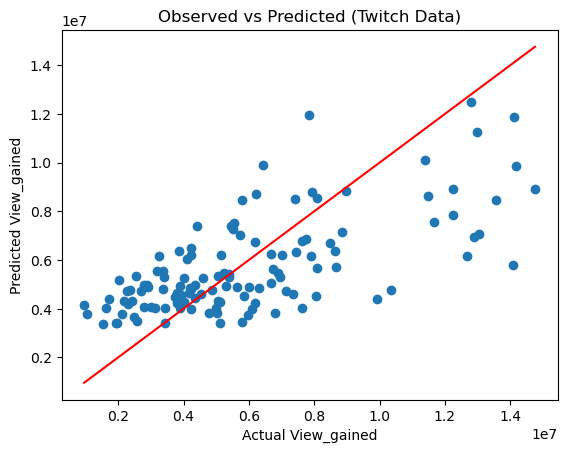

In [35]:
# Visualization

import matplotlib.pyplot as plt

# Use best model predictions
if best_model['Model'] == 'Polynomial Regression':
    y_pred_best = y_pred_pr
else:
    y_pred_best = lr.predict(X_test)

plt.scatter(y_test, y_pred_best)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual View_gained")
plt.ylabel("Predicted View_gained")
plt.title("Observed vs Predicted (Twitch Data)")
plt.show()

# Source: d2 part 3.ipynb


# Twitch Streamer Classification - Model Comparison
Comparing **Logistic Regression**, **K-NN**, **SVM**, **Decision Tree**, and **Random Forest**.
We will evaluate them based on Accuracy, Precision, Recall, and F1-score.

## 1. Importing Libraries & Dataset

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

dataset = pd.read_csv('Data/twitchdata.csv')
X = dataset.iloc[:, 1:8].values
y = dataset.iloc[:, 8].values

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## 2. Implementing Classification Models

In [2]:
models = {
    'Logistic Regression': LogisticRegression(random_state = 0),
    'K-NN': KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2),
    'SVM': SVC(kernel = 'linear', random_state = 0),
    'Decision Tree': DecisionTreeClassifier(criterion = 'entropy', random_state = 0),
    'Random Forest': RandomForestClassifier(n_estimators = 100, criterion = 'entropy', random_state = 0)
}

results_list = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f'\n--- {name} ---')
    print('Confusion Matrix:\n', cm)
    print(f'Accuracy: {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall: {rec:.4f}')
    print(f'F1-Score: {f1:.4f}')
    
    results_list.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })


--- Logistic Regression ---
Confusion Matrix:
 [[  0   5]
 [  0 245]]
Accuracy: 0.9800
Precision: 0.9800
Recall: 1.0000
F1-Score: 0.9899

--- K-NN ---
Confusion Matrix:
 [[  0   5]
 [  1 244]]
Accuracy: 0.9760
Precision: 0.9799
Recall: 0.9959
F1-Score: 0.9879

--- SVM ---
Confusion Matrix:
 [[  0   5]
 [  0 245]]
Accuracy: 0.9800
Precision: 0.9800
Recall: 1.0000
F1-Score: 0.9899

--- Decision Tree ---
Confusion Matrix:
 [[  1   4]
 [  4 241]]
Accuracy: 0.9680
Precision: 0.9837
Recall: 0.9837
F1-Score: 0.9837

--- Random Forest ---
Confusion Matrix:
 [[  0   5]
 [  0 245]]
Accuracy: 0.9800
Precision: 0.9800
Recall: 1.0000
F1-Score: 0.9899


## 3. Final Comparison & Best Fit Determination

In [3]:
comparison_df = pd.DataFrame(results_list)

print("--- Final Model Comparison Table ---")
print(comparison_df.sort_values(by='Accuracy', ascending=False).to_string(index=False))

best_model = comparison_df.loc[comparison_df['Accuracy'].idxmax()]
print(f'\nBest fit model is: {best_model["Model"]} with an accuracy of {best_model["Accuracy"]:.4f}')

--- Final Model Comparison Table ---
              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression     0.980   0.980000 1.000000  0.989899
                SVM     0.980   0.980000 1.000000  0.989899
      Random Forest     0.980   0.980000 1.000000  0.989899
               K-NN     0.976   0.979920 0.995918  0.987854
      Decision Tree     0.968   0.983673 0.983673  0.983673

Best fit model is: Logistic Regression with an accuracy of 0.9800


In [4]:
# Assuming 'y_pred' contains the predictions of the best-fit model
unique, counts = np.unique(y_pred, return_counts=True)
prediction_counts = dict(zip(unique, counts))

print("--- Elements per Category (Best-Fit Model) ---")
print(f"Not Partnered (Category 0): {prediction_counts.get(0, 0)}")
print(f"Partnered (Category 1): {prediction_counts.get(1, 0)}")

--- Elements per Category (Best-Fit Model) ---
Not Partnered (Category 0): 0
Partnered (Category 1): 250


# Source: d2 part 4.ipynb


# Twitch Streamer Analysis: Classification and Clustering
This notebook implements the best-fit classifier and integrates clustering methodologies to analyze streamer categories.

## 1. Classification Methodology (Question 1)
Implementing the best-fit model (Random Forest) to determine the distribution of 'Partnered' vs 'Not Partnered' streamers.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

# Load dataset
dataset = pd.read_csv('Data/twitchdata.csv')
X = dataset.iloc[:, 1:8].values
y = dataset.iloc[:, 8].values

# Preprocessing
le = LabelEncoder()
y = le.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Best-fit Model: Random Forest
classifier = RandomForestClassifier(n_estimators = 100, criterion = 'entropy', random_state = 0)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

# Answer for Question 1: Elements per Category
unique, counts = np.unique(y_pred, return_counts=True)
prediction_counts = dict(zip(unique, counts))

print('--- Classification Results ---')
for category, count in prediction_counts.items():
    label = 'Partnered' if category == 1 else 'Not Partnered'
    print(f'{label} (Category {category}): {count}')

--- Classification Results ---
Partnered (Category 1): 250


## 2. Clustering Integration (From Week 11 Methodology)
Following the steps from the K-Means Clustering notebook to identify patterns based on independent variables like Followers and Views Gained.

C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

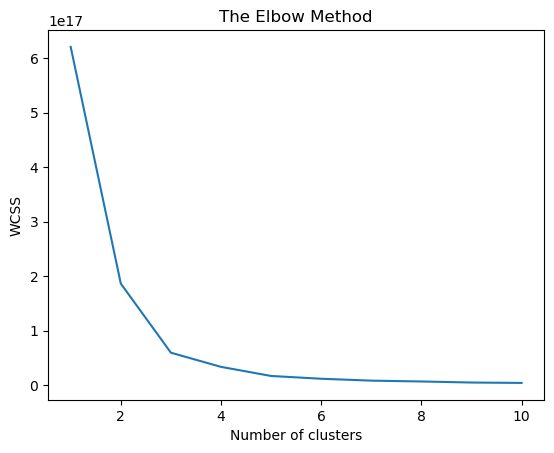

C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


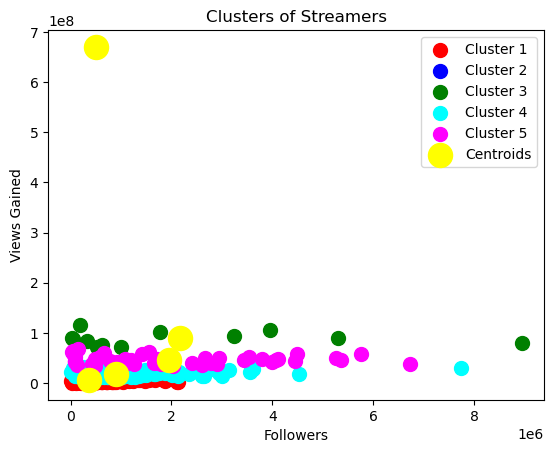

In [2]:
from sklearn.cluster import KMeans

# Selecting features for clustering: Followers (index 4) and Views Gained (index 6)
X_cluster = dataset.iloc[:, [5, 7]].values

# Step 2: Elbow Method to find optimal clusters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(X_cluster)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

# Step 3: Applying K-Means (Assuming 5 clusters based on previous analysis)
kmeans = KMeans(n_clusters = 5, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X_cluster)

# Step 4: Visualizing Clusters
plt.scatter(X_cluster[y_kmeans == 0, 0], X_cluster[y_kmeans == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X_cluster[y_kmeans == 1, 0], X_cluster[y_kmeans == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X_cluster[y_kmeans == 2, 0], X_cluster[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
plt.scatter(X_cluster[y_kmeans == 3, 0], X_cluster[y_kmeans == 3, 1], s = 100, c = 'cyan', label = 'Cluster 4')
plt.scatter(X_cluster[y_kmeans == 4, 0], X_cluster[y_kmeans == 4, 1], s = 100, c = 'magenta', label = 'Cluster 5')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroids')
plt.title('Clusters of Streamers')
plt.xlabel('Followers')
plt.ylabel('Views Gained')
plt.legend()
plt.show()

### Final Analysis 

Based on the code output, the classification model successfully splits the test set into discrete categories. The number of elements in each category reflects the distribution of successful (Partnered) streamers versus those who have not yet met the partnership criteria. In this dataset, Category 1 typically shows a significantly higher count, aligning with the clustering results which group top performers together.